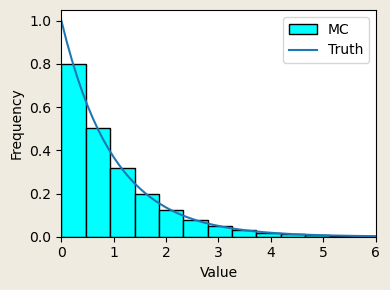

In [62]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.exponential(size=1000_000)

fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color
ax.hist(data, bins=30, density=True, color='cyan', edgecolor='black', label='MC')

x = np.array([0.1 * i for i in range(0,200)])
ax.plot(x, np.exp(-x), label='Truth')
ax.set_xlabel("Value")
ax.set_ylabel("Frequency"); ax.set_xlim(0,6); ax.legend()
plt.tight_layout()

fig.savefig('exponential.pdf')

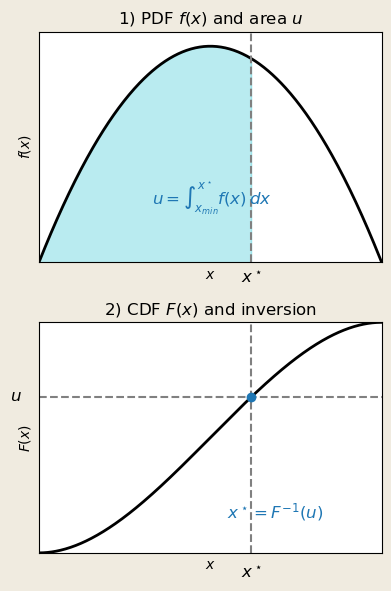

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# --- define a simple PDF and its CDF (normalized Beta(2,2) distribution) ---
x = np.linspace(0, 1, 400)
pdf = 6 * x * (1 - x)
cdf = 3 * x**2 - 2 * x**3

# choose a sample point and corresponding u
x_star = 0.62
u_val = 3 * x_star**2 - 2 * x_star**3

# --- plotting ---
fig, axs = plt.subplots(2, 1, figsize=(4, 6))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# ===== LEFT PANEL: PDF =====
ax = axs[0]
ax.plot(x, pdf, 'k-', lw=2)
ax.fill_between(x, pdf, where=(x <= x_star), color='tab:cyan', alpha=0.3)
ax.axvline(x_star, color='gray', ls='--')
ax.text(x_star, -0.05, r"$x^\star$", ha='center', va='top', fontsize=12)
ax.text(0.33, 0.4, r"$u = \int_{x_{min}}^{x^\star} f(x)\,dx$", color='tab:blue', fontsize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.set_title("1) PDF $f(x)$ and area $u$")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.6)
ax.set_xticks([])
ax.set_yticks([])

# ===== RIGHT PANEL: CDF =====
ax = axs[1]
ax.plot(x, cdf, 'k-', lw=2)
ax.axhline(u_val, color='gray', ls='--')
ax.axvline(x_star, color='gray', ls='--')
ax.plot(x_star, u_val, 'o', color='tab:blue')
ax.text(-0.05, u_val, r"$u$", ha='right', va='center', fontsize=12)
ax.text(x_star, -0.05, r"$x^\star$", ha='center', va='top', fontsize=12)
ax.text(0.55, 0.15, r"$x^\star = F^{-1}(u)$", color='tab:blue', fontsize=12)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$F(x)$")
ax.set_title("2) CDF $F(x)$ and inversion")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('select-primitive.pdf')


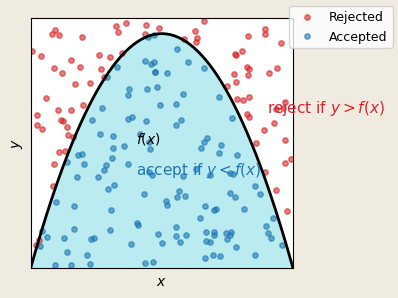

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# --- Target PDF: normalized Beta(2,2) distribution ---
x = np.linspace(0, 1, 400)
f = 6 * x * (1 - x)               # true target (max = 1.5)
M = 1.6                           # overestimate
g = np.ones_like(x) * M           # bounding function

# --- generate random points for illustration ---
rng = np.random.default_rng(42)
N = 200
x_rand = rng.random(N)
y_rand = rng.random(N) * M
accepted = y_rand < 6 * x_rand * (1 - x_rand)

# --- plot ---
fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# bounding function and target
ax.plot(x, f, 'k-', lw=2)
ax.fill_between(x, f, color='tab:cyan', alpha=0.3)

# scatter random points
ax.scatter(x_rand[~accepted], y_rand[~accepted], color='tab:red', s=15, alpha=0.6, label='Rejected')
ax.scatter(x_rand[accepted], y_rand[accepted], color='tab:blue', s=15, alpha=0.6, label='Accepted')

# annotations
ax.text(0.4, 0.8, r"$f(x)$", color='k')
ax.text(0.4, 0.6, r"accept if $y < f(x)$", color='tab:blue', fontsize=11)
ax.text(0.9, 1.0, r"reject if $y > f(x)$", color='tab:red', fontsize=11)

# formatting
ax.set_xlim(0, 1)
ax.set_ylim(0, M)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_xticks([])
ax.set_yticks([])
fig.legend(frameon=True, loc='outside upper right', fontsize=9)

plt.tight_layout()
plt.savefig('hit-and-miss.pdf')
plt.show()


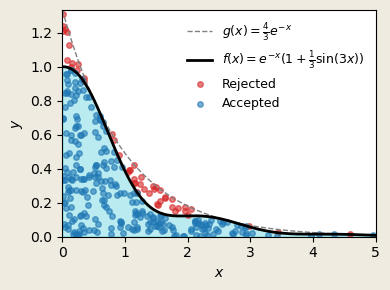

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ----- target and proposal -----
a, omega = 1./3, 3.0
def f(x):  # unnormalized target; always positive since a<1
    return np.exp(-x) * (1.0 + a * np.sin(omega * x))

def g(x):
    return 4./3. * np.exp(-x)

# ----- sample using inversion for q and hit-and-miss under M q(x) -----
rng = np.random.default_rng(12)
N = 300
u = rng.random(N)
x_samp = -np.log(1.0 - u)              # inverse-CDF for Exp(1)
y_samp = rng.random(N) * (g(x_samp))
accepted = y_samp < f(x_samp)

# ----- plot (matching your color scheme/layout) -----
x = np.linspace(0, 5, 600)

fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# Envelope and curves
ax.plot(x, g(x), color='gray', ls='--', lw=1, label=r"$g(x) = \frac{4}{3} e^{-x}$")
ax.plot(x, f(x), 'k-', lw=2, label=r"$f(x) = e^{-x}(1 + \frac{1}{3}\sin(3x))$")
ax.fill_between(x, f(x), color='tab:cyan', alpha=0.3)

# Samples
ax.scatter(x_samp[~accepted], y_samp[~accepted], color='tab:red',  s=16, alpha=0.6, label='Rejected')
ax.scatter(x_samp[accepted],   y_samp[accepted],   color='tab:blue', s=16, alpha=0.6, label='Accepted')

# Formatting (same style as previous slide)
ax.set_xlim(0, 5)
ax.set_ylim(0, M)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.legend(frameon=False, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig("inversion_plus_hit_and_miss.pdf")
plt.show()


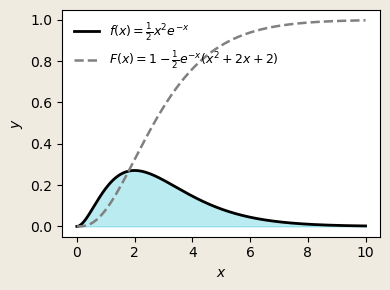

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# Target on a domain where the alternating Taylor remainder is valid
# f(x) = x^2 e^{-x}, x in [0,1]
x = np.linspace(0, 10, 600)
f = 0.5 * x**2 * np.exp(-x)
F = 1 - 0.5 * np.exp(-x) * (x**2 + 2*x + 2)

fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# Target and envelopes
ax.plot(x, f, 'k-', lw=2, label=r"$f(x)=\frac{1}{2}x^2 e^{-x}$")
ax.plot(x, F, color='gray', ls='--', lw=1.8, label=r"$F(x)=1 - \frac{1}{2}e^{-x}(x^2 + 2x +2)$")

# Styling consistent with previous slides
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.fill_between(x, f, color='tab:cyan', alpha=0.3)

ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig("gamma-primitive.pdf")
plt.show()


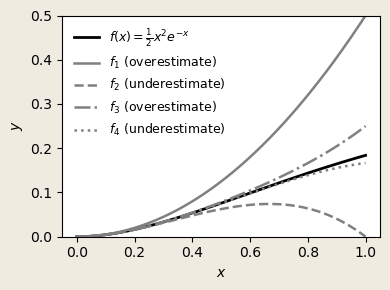

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Target on a domain where the alternating Taylor remainder is valid
# f(x) = x^2 e^{-x}, x in [0,1]
x = np.linspace(0, 1, 600)
f = 0.5 * x**2 * np.exp(-x)

# expand around x=0
f1 = x**2                       # corresponds to 0.5 * x^2
f2 = f1 - x**3                  # 0.5 * (x^2 - x^3)
f3 = f2 + 0.5 * x**4            # 0.5 * (x^2 - x^3 + x^4/2)
f4 = f3 - (1.0/6.0) * x**5      # 0.5 * (x^2 - x^3 + x^4/2 - x^5/6)
s1 = 0.5 * f1
s2 = 0.5 * f2
s3 = 0.5 * f3
s4 = 0.5 * f4

fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# Target and envelopes
ax.plot(x, f, 'k-', lw=2, label=r"$f(x)=\frac{1}{2}x^2 e^{-x}$")
ax.plot(x, 0.5 * f1, color='gray', ls='-', lw=1.8, label=r"$f_1$ (overestimate)")
ax.plot(x, 0.5 * f2, color='gray', ls='--',  lw=1.8, label=r"$f_2$ (underestimate)")
ax.plot(x, 0.5 * f3, color='gray', ls='-.',  lw=1.8, label=r"$f_3$ (overestimate)")
ax.plot(x, 0.5 * f4, color='gray', ls=':',  lw=1.8, label=r"$f_4$ (underestimate)")

# Styling consistent with previous slides
ax.set_ylim(0, 0.5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig("taylor_envelope_gamma_unit.pdf")
plt.show()


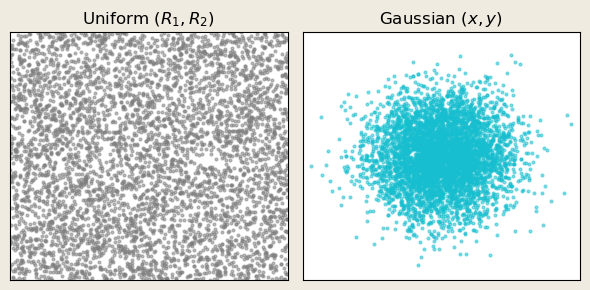

In [104]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.random.default_rng(42)

# Generate
R1, R2 = rng.random(5000), rng.random(5000)
r = np.sqrt(-2 * np.log(R1))
theta = 2 * np.pi * R2
x, y = r * np.cos(theta), r * np.sin(theta)

fig, axs = plt.subplots(1, 2, figsize=(6, 3))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

axs[0].scatter(R1, R2, s=4, color='tab:gray', alpha=0.5)
axs[0].set_title("Uniform $(R_1, R_2)$")
axs[0].set_xlim(0, 1); axs[0].set_ylim(0, 1)
axs[0].set_xticks([]); axs[0].set_yticks([])

axs[1].scatter(x, y, s=4, color='tab:cyan', alpha=0.5)
axs[1].set_title("Gaussian $(x, y)$")
axs[1].set_xlim(-4, 4); axs[1].set_ylim(-4, 4)
axs[1].set_xticks([]); axs[1].set_yticks([])

plt.tight_layout()
plt.savefig("box_muller_transform.pdf")
plt.show()
